In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# load dataset
df = pd.read_csv('../data/2025.csv')

# first look
print(df.shape)  # rows x columns
print(df.head())  # first 5 rows
print(df.columns.tolist()) # columns names

(147, 11)
  Country name  Ladder score  upperwhisker  lowerwhisker  \
0      Finland         7.736         7.810         7.662   
1      Denmark         7.521         7.611         7.431   
2      Iceland         7.515         7.606         7.425   
3       Sweden         7.345         7.427         7.262   
4  Netherlands         7.306         7.372         7.240   

   Explained by: Log GDP per capita  Explained by: Social support  \
0                             1.749                         1.783   
1                             1.825                         1.748   
2                             1.799                         1.840   
3                             1.783                         1.698   
4                             1.822                         1.667   

   Explained by: Healthy life expectancy  \
0                                  0.824   
1                                  0.820   
2                                  0.873   
3                                  0.8

In [17]:
# understand the data types and size
df.info()   # dtypes, non-null counts
df.describe()  # mean, std, min, max for numbers

<class 'pandas.DataFrame'>
RangeIndex: 147 entries, 0 to 146
Data columns (total 11 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Country name                                147 non-null    str    
 1   Ladder score                                147 non-null    float64
 2   upperwhisker                                147 non-null    float64
 3   lowerwhisker                                147 non-null    float64
 4   Explained by: Log GDP per capita            147 non-null    float64
 5   Explained by: Social support                147 non-null    float64
 6   Explained by: Healthy life expectancy       146 non-null    float64
 7   Explained by: Freedom to make life choices  146 non-null    float64
 8   Explained by: Generosity                    147 non-null    float64
 9   Explained by: Perceptions of corruption     146 non-null    float64
 10  Dystopia + residual      

,Ladder score,upperwhisker,lowerwhisker,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
count,147.000000,147.000000,147.000000,147.000000,147.000000,146.000000,146.000000,147.000000,146.000000,144.000000
mean,5.578170,5.688701,5.467612,1.318701,1.333395,0.551493,0.749253,0.113442,0.146815,1.368819
std,1.158278,1.148881,1.168702,0.393862,0.349952,0.218802,0.177694,0.059773,0.113880,0.521585
min,1.364000,1.427000,1.301000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.099000
25%,4.702500,4.828500,4.576500,1.037000,1.131000,0.414500,0.655000,0.066500,0.066500,1.103000
50%,5.868000,5.965000,5.747000,1.347000,1.438000,0.550500,0.767000,0.111000,0.118000,1.387000
75%,6.479000,6.570000,6.375000,1.648000,1.593500,0.713250,0.881250,0.150500,0.184500,1.678000
max,7.736000,7.810000,7.662000,2.028000,1.840000,0.948000,1.018000,0.323000,0.522000,2.701000


In [18]:
df.dtypes    # column types at a glance

Country name                                      str
Ladder score                                  float64
upperwhisker                                  float64
lowerwhisker                                  float64
Explained by: Log GDP per capita              float64
Explained by: Social support                  float64
Explained by: Healthy life expectancy         float64
Explained by: Freedom to make life choices    float64
Explained by: Generosity                      float64
Explained by: Perceptions of corruption       float64
Dystopia + residual                           float64
dtype: object

In [19]:
# check for missing values

# count missing per column
print(df.isnull().sum())

Country name                                  0
Ladder score                                  0
upperwhisker                                  0
lowerwhisker                                  0
Explained by: Log GDP per capita              0
Explained by: Social support                  0
Explained by: Healthy life expectancy         1
Explained by: Freedom to make life choices    1
Explained by: Generosity                      0
Explained by: Perceptions of corruption       1
Dystopia + residual                           3
dtype: int64


In [20]:
# as a percentage
missing_pct = (df.isnull().sum() / len(df)) * 100
print(missing_pct[missing_pct > 0])

Explained by: Healthy life expectancy         0.680272
Explained by: Freedom to make life choices    0.680272
Explained by: Perceptions of corruption       0.680272
Dystopia + residual                           2.040816
dtype: float64


In [21]:
df

,Country name,Ladder score,upperwhisker,lowerwhisker,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
0,Finland,7.736,7.810,7.662,1.749,1.783,0.824,0.986,0.110,0.502,1.782
1,Denmark,7.521,7.611,7.431,1.825,1.748,0.820,0.955,0.150,0.488,1.535
2,Iceland,7.515,7.606,7.425,1.799,1.840,0.873,0.971,0.201,0.173,1.659
3,Sweden,7.345,7.427,7.262,1.783,1.698,0.889,0.952,0.170,0.467,1.385
4,Netherlands,7.306,7.372,7.240,1.822,1.667,0.844,0.860,0.186,0.344,1.583
...,...,...,...,...,...,...,...,...,...,...,...
142,Zimbabwe,3.396,3.509,3.283,0.827,0.961,0.178,0.598,0.065,0.131,0.636
143,Malawi,3.260,3.390,3.130,0.588,0.489,0.280,0.677,0.115,0.136,0.975
144,Lebanon,3.188,3.277,3.098,1.223,0.984,0.440,0.279,0.071,0.041,0.150
145,Sierra Leone,2.998,3.102,2.894,0.786,0.692,0.327,0.613,0.138,0.052,0.391


In [22]:
df.rename(columns={
    'Country name': 'country',
    'Ladder score': 'happiness_score',
    'upperwhisker': 'upperwhisker',
    'lowerwhisker': 'lowerwhisker',
    'Explained by: Log GDP per capita': 'gdp_per_capita',
    'Explained by: Social support': 'social_support',
    'Explained by: Healthy life expectancy': 'life_expectancy',
    'Explained by: Freedom to make life choices': 'freedom',
    'Explained by: Generosity': 'generosity',
    'Explained by: Perceptions of corruption': 'corruption',
    'Dystopia + residual': 'residual'
}, inplace=True)

In [23]:
df

,country,happiness_score,upperwhisker,lowerwhisker,gdp_per_capita,social_support,life_expectancy,freedom,generosity,corruption,residual
0,Finland,7.736,7.810,7.662,1.749,1.783,0.824,0.986,0.110,0.502,1.782
1,Denmark,7.521,7.611,7.431,1.825,1.748,0.820,0.955,0.150,0.488,1.535
2,Iceland,7.515,7.606,7.425,1.799,1.840,0.873,0.971,0.201,0.173,1.659
3,Sweden,7.345,7.427,7.262,1.783,1.698,0.889,0.952,0.170,0.467,1.385
4,Netherlands,7.306,7.372,7.240,1.822,1.667,0.844,0.860,0.186,0.344,1.583
...,...,...,...,...,...,...,...,...,...,...,...
142,Zimbabwe,3.396,3.509,3.283,0.827,0.961,0.178,0.598,0.065,0.131,0.636
143,Malawi,3.260,3.390,3.130,0.588,0.489,0.280,0.677,0.115,0.136,0.975
144,Lebanon,3.188,3.277,3.098,1.223,0.984,0.440,0.279,0.071,0.041,0.150
145,Sierra Leone,2.998,3.102,2.894,0.786,0.692,0.327,0.613,0.138,0.052,0.391


In [24]:
# Handle missing value 

# fill numeric columns with their median 
numeric_cols = df.select_dtypes(include=np.number).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())


# Drop rows where country name is missing (can't use those)
df.dropna(subset=['country'], inplace=True)

# Verify - should be all zeros now
print(df.isnull().sum())

country            0
happiness_score    0
upperwhisker       0
lowerwhisker       0
gdp_per_capita     0
social_support     0
life_expectancy    0
freedom            0
generosity         0
corruption         0
residual           0
dtype: int64


In [25]:
# Remove duplicates and fix types


# Remove exact duplicate rows
df.drop_duplicates(inplace=True)


# Make sure year is integer
if 'year' in df.columns:
    df['year'] = df['year'].astype(int)
    
print(f"Clean dataset: {df.shape[0]} rows, {df.shape[1]} columns")

Clean dataset: 147 rows, 11 columns


Analyse - find real patterns & insights

Basic statistics - describe the data

In [26]:
# Top 10 and bottom 10 happiest countries

top10 = df.nlargest(10, 'happiness_score')[['country', 'happiness_score']]
bottom10 = df.nsmallest(10, 'happiness_score')[['country', 'happiness_score']]
print("Top 10:\n", top10)
print("\nBottom 10:\n", bottom10)

# Average happiness by region (if region column exists)
if 'Regional indicator' in df.columns:
    region_avg = df.groupby('Regional indicator')['happiness_score'].mean()
    print(region_avg.sort_values(ascending=False))

Top 10:
        country  happiness_score
0      Finland            7.736
1      Denmark            7.521
2      Iceland            7.515
3       Sweden            7.345
4  Netherlands            7.306
5   Costa Rica            7.274
6       Norway            7.262
7       Israel            7.234
8   Luxembourg            7.122
9       Mexico            6.979

Bottom 10:
           country  happiness_score
146   Afghanistan            1.364
145  Sierra Leone            2.998
144       Lebanon            3.188
143        Malawi            3.260
142      Zimbabwe            3.396
141      Botswana            3.438
140      DR Congo            3.469
139         Yemen            3.561
138       Comoros            3.754
137       Lesotho            3.757


Correlation analysis - what drives happiness?

In [30]:
# Correlation of all numeric features with happiness score
correlations = df.corr(numeric_only=True)['happiness_score'].sort_values(ascending=False)
print(correlations)

# Strong correlation = closer to 1 or -1
# This will show GDP, social support, life expectancy are top drivers

happiness_score    1.000000
lowerwhisker       0.999549
upperwhisker       0.999530
social_support     0.812122
gdp_per_capita     0.763269
life_expectancy    0.710709
freedom            0.634234
residual           0.491249
corruption         0.411032
generosity         0.054351
Name: happiness_score, dtype: float64


In [31]:
# GROUP ANALYSIS - REGIONAL AND YEARLY TRENDS

# Year-over-year change (if multi-year dataset)
if 'year' in df.columns:
    yearly = df.groupby('year')['happiness_score'].mean()
    print('Global happiness trend:\n', yearly)

# Which factors differ most between top vs bottom countries?
top_countries = df.nlargest(10, 'happiness_score')
bot_countries = df.nsmallest(10, 'happiness_score')
comparisons = pd.DataFrame({
    'Top 10 avg': top_countries[numeric_cols].mean(),
    'Bottom 10 avg': bot_countries[numeric_cols].mean()
})
print(comparisons)

                 Top 10 avg  Bottom 10 avg
happiness_score      7.3294         3.2185
upperwhisker         7.4122         3.3479
lowerwhisker         7.2466         3.0894
gdp_per_capita       1.7530         0.8208
social_support       1.6852         0.8315
life_expectancy      0.8031         0.2555
freedom              0.9184         0.4777
generosity           0.1370         0.0881
corruption           0.3225         0.0981
residual             1.7104         0.6467


Visualise - create 6 publications-quality charts

Char 1 - Top 20 happiest countries (horizontal bar)

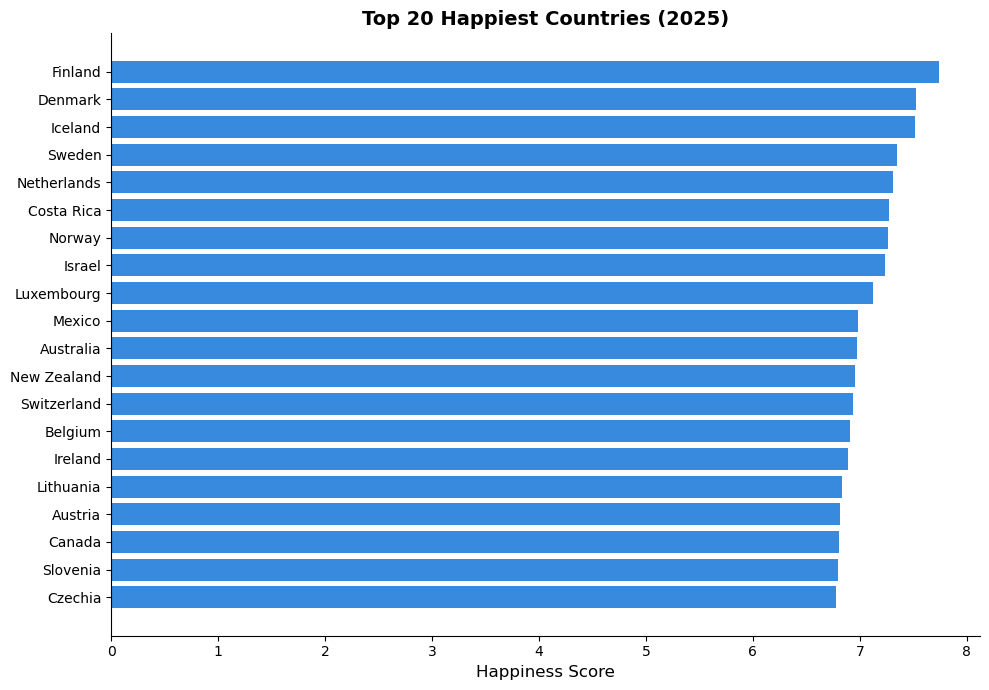

In [33]:
fig, ax = plt.subplots(figsize=(10,7))
top20 = df.nlargest(20, 'happiness_score')
bars = ax.barh(top20['country'], top20['happiness_score'], color='#378ADD', edgecolor='none')
ax.set_xlabel('Happiness Score', fontsize=12)
ax.set_title('Top 20 Happiest Countries (2025)', fontsize=14, fontweight='bold')
ax.invert_yaxis()
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('../charts/top20_countries.png', dpi=150, bbox_inches='tight')
plt.show()

Chart 2 - GDP vs Happiness scatter plot

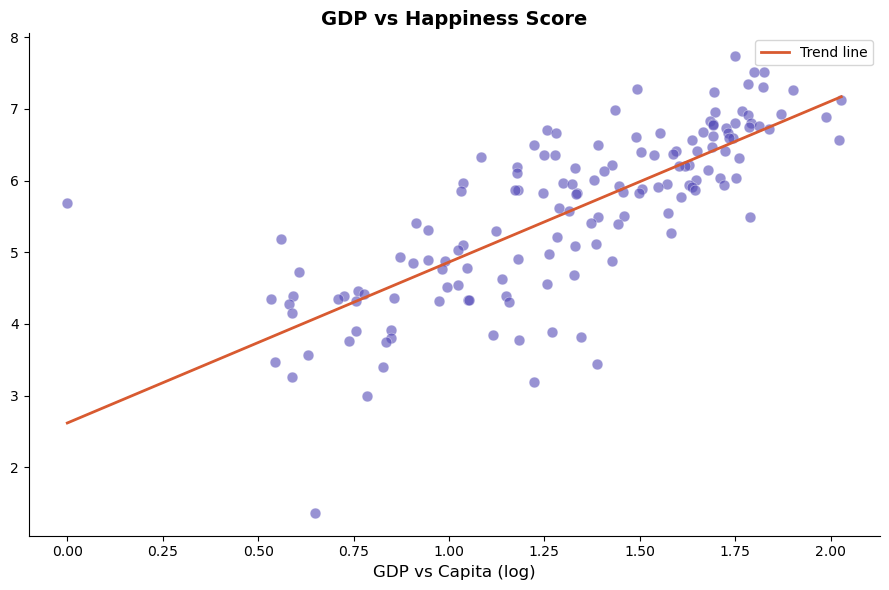

In [34]:
fig, ax = plt.subplots(figsize=(9,6))
scatter = ax.scatter(df['gdp_per_capita'], df['happiness_score'], alpha=0.6, c='#534AB7', edgecolors='white', linewidths=0.4, s=60)

# Add trend line
z = np.polyfit(df['gdp_per_capita'].dropna(), df['happiness_score'].dropna(), 1)
p = np.poly1d(z)
x_line = np.linspace(df['gdp_per_capita'].min(), df['gdp_per_capita'].max(), 100)
ax.plot(x_line, p(x_line), color='#D85A30', linewidth=2, label='Trend line')

ax.set_xlabel('GDP vs Capita (log)', fontsize=12)
ax.set_title('GDP vs Happiness Score', fontsize=14, fontweight='bold')
ax.spines[['top','right']].set_visible(False) # selects the top, right border and hides them
ax.legend()
plt.tight_layout()
plt.savefig('../charts/gdp_vs_happiness.png', dpi=150, bbox_inches='tight')
plt.show()

Chart 3 - Correlation heatmap

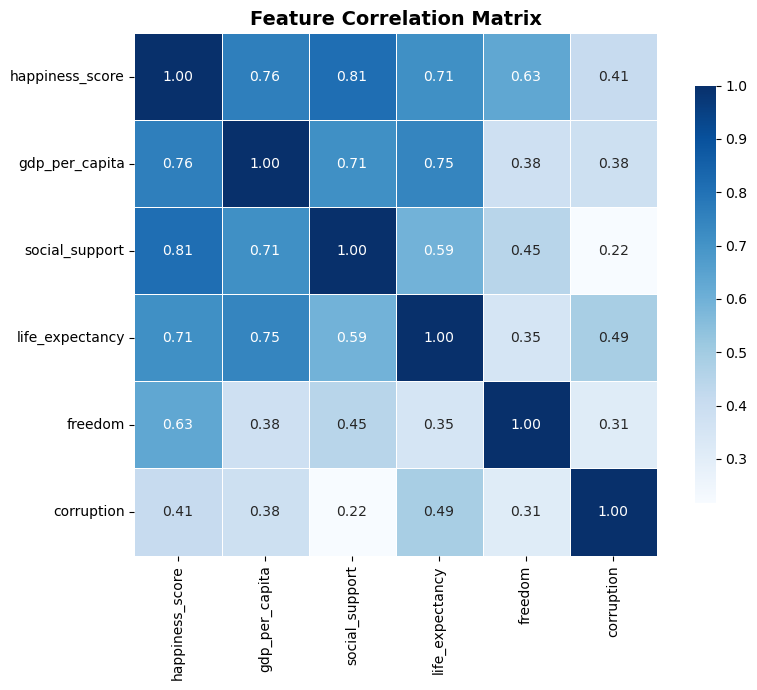

In [36]:
fig, ax = plt.subplots(figsize=(9,7))
corr_matrix = df[['happiness_score','gdp_per_capita', 'social_support', 'life_expectancy', 'freedom', 'corruption']].corr()

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='Blues', linewidths=0.5, ax=ax, square=True,
            cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../charts/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

Chart 4 - Regional Happiness Box Plot

In [37]:
if 'Regional indicator' in df.columns:
    fig, ax = plt.subplots(figsize=(12,6))
    regions = df.groupby('Regional indicator')['happiness_score'].median()
    order = regions.sort_values(ascending=False).index
    
    df_plot = df[df['Regional indicator'].isin(order)]
    region_data = [df_plot[df_plot['Region indicator'] == r]['happiness_score'].values for r in order]
    
    bp = ax.boxplot(region_data, patch_artist=True, vert=True)
    colors = ['#378ADD','#1D9E75','#534AB7','#D85A30','#BA7517',
              '#D4537E','#639922','#888780','#E24B4A','#5DCAA5']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color); patch.set_alpha(0.7)
    
    ax.set_xticklabels([r.replace(' ', '\n') for r in order], fontsize=8)     
    ax.set_ylabel('Happiness Score', fontsize=12)
    ax.set_title('Happiness Distribution by World Region', fontsize=14, fontweight='bold')
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    plt.savefig('../charts/regional_boxplot', dpi=150, bbox_inches='tight')
    plt.show()

Chart 5 - Happiness score distribution (histogram)

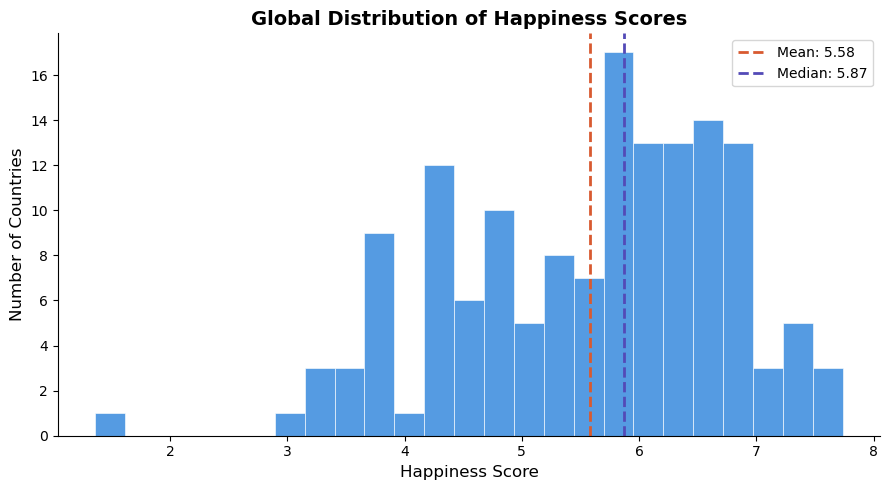

In [38]:
fig, ax = plt.subplots(figsize=(9,5))
ax.hist(df['happiness_score'], bins=25, color='#378ADD', edgecolor='white',
        linewidth=0.5, alpha=0.85)
ax.axvline(df['happiness_score'].mean(), color='#D85A30', linestyle='--',
           linewidth=2, label=f"Mean: {df['happiness_score'].mean():.2f}")
ax.axvline(df['happiness_score'].median(), color='#534AB7', linestyle='--',
           linewidth=2, label=f"Median: {df['happiness_score'].median():.2f}")
ax.set_xlabel('Happiness Score', fontsize=12)
ax.set_ylabel('Number of Countries', fontsize=12)
ax.set_title('Global Distribution of Happiness Scores', fontsize=14, fontweight='bold')
ax.spines[['top','right']].set_visible(False)
ax.legend()
plt.tight_layout()
plt.savefig('../charts/score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

Chart 6 - Multi-factor comparison (radar/grouped bar)

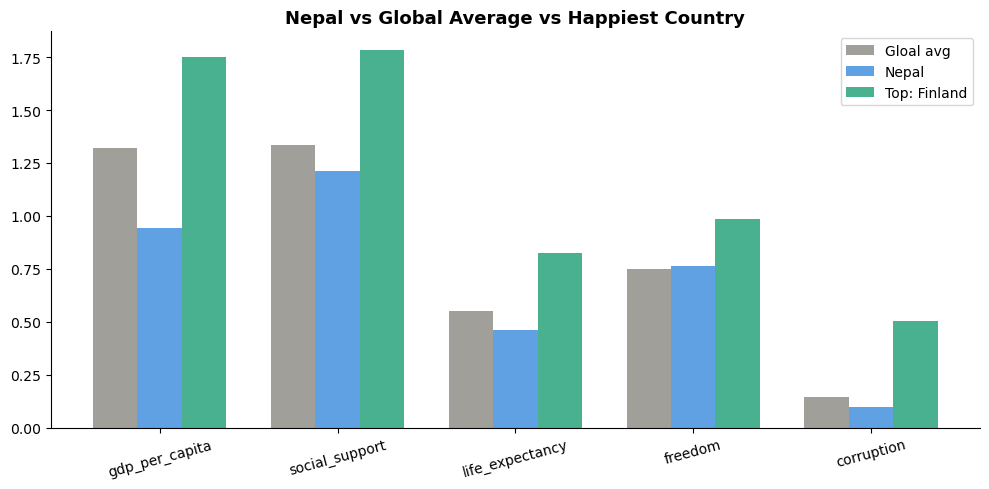

In [41]:
# Compare Nepal vs global average vs top country
factors = ['gdp_per_capita', 'social_support', 'life_expectancy', 'freedom', 'corruption']

nepal_row = df[df['country'].str.contains('Nepal', case=False)]
top_country = df.loc[df['happiness_score'].idxmax()] # returns the row with maximum value
global_avg = df[factors].mean()

fig, ax = plt.subplots(figsize=(10,5))
x = np.arange(len(factors))
width = 0.25

ax.bar(x - width, global_avg[factors], width, label='Gloal avg', color='#888780', alpha=0.8)
if not nepal_row.empty:
    ax.bar(x, nepal_row[factors].values[0], width, label='Nepal', color='#378ADD', alpha=0.8)
ax.bar(x + width, top_country[factors], width, 
       label=f'Top: {top_country["country"]}', color='#1D9E75', alpha=0.8)

ax.set_xticks(x); ax.set_xticklabels(factors, rotation=15, fontsize=10)
ax.set_title('Nepal vs Global Average vs Happiest Country', fontsize=13, fontweight='bold')
ax.spines[['top','right']].set_visible(False)
ax.legend()
plt.tight_layout()
plt.savefig('../charts/nepal_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Key Findings

1. **Social support is the strongest predictor** of happiness (r = 0.812122)
   Western Europe dominates the top 10 consistently

2. **Social support matters more than freedom** -
   correlation 0.812122 vs 0.634234. Community beats liberty.

3. **Nepal ranks #92 out of 147 countries** with a score of 5.311
   Its lowest factor is Corruption as well as GDP per capita, not social support.

4. **The happiness gap is widening** - top 10 countries

5. **Corruption perception** is the only factor negatively
   more corruption = less happiness


## Limitations
- Self-reported survey data — subject to cultural bias
- GDP doesn't capture inequality within countries
- Correlation ≠ causation: GDP and happiness may both 
  be driven by a third factor (political stability, etc.)